In [ ]:
# Cell 1: imports + generate synthetic data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n_calm = 200
n_turbulent = 200
dates = pd.date_range("2025-08-01", periods=n_calm + n_turbulent, freq="B")

# Regime 1: calm phase — small upward drift, small day-to-day noise
regime1 = np.cumsum(np.random.normal(loc=0.02, scale=0.15, size=n_calm))

# Regime 2: turbulent phase — drift REVERSES, volatility triples
# (this mimics what a real shock does: not just noisier, direction flips)
regime2 = np.cumsum(np.random.normal(loc=-0.05, scale=0.45, size=n_turbulent))

series = np.concatenate([regime1, regime2 + regime1[-1]])
price = 1.27 + series / 100

df = pd.DataFrame({"date": dates, "price": price})
print(f"True regime break at index {n_calm}, date {dates[n_calm].date()}")

True regime break at index 200, date 2026-05-08


In [ ]:
df

,date,price
0,2025-08-01,1.270945
1,2025-08-04,1.270938
2,2025-08-05,1.272109
3,2025-08-06,1.274594
4,2025-08-07,1.274443
...,...,...
395,2027-02-05,1.273612
396,2027-02-08,1.265403
397,2027-02-09,1.270995
398,2027-02-10,1.269980


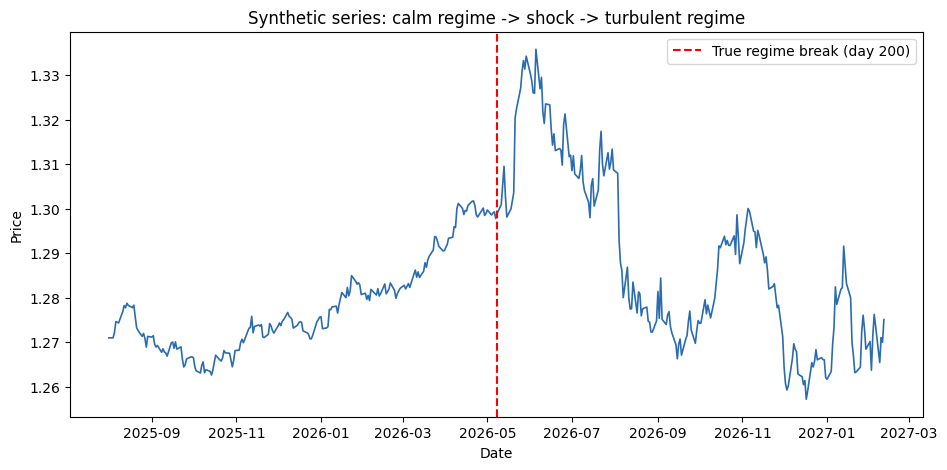

In [ ]:
# Cell 2: visualize it — SEE the regime shift before modeling anything
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df["date"], df["price"], color="#2b6cb0", linewidth=1.2)
ax.axvline(df["date"].iloc[200], color="red", linestyle="--", label="True regime break (day 200)")
ax.set_title("Synthetic series: calm regime -> shock -> turbulent regime")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
plt.show()

## MA

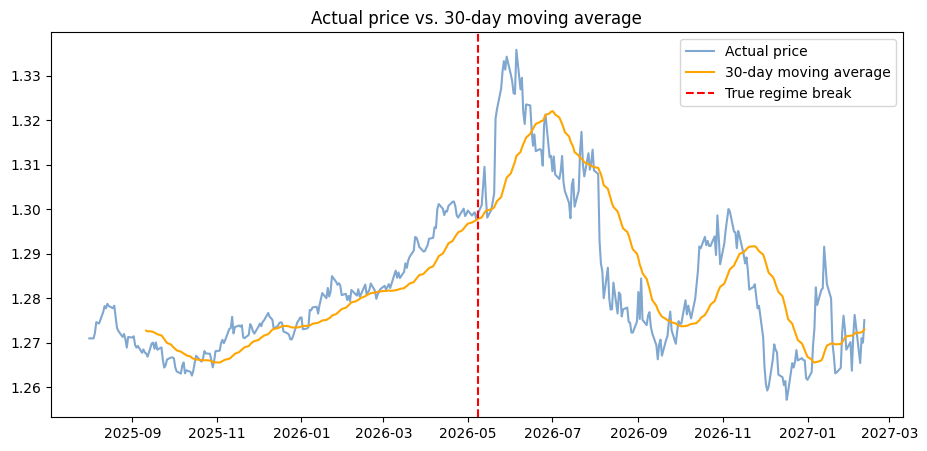

In [ ]:
# Cell 3: simple moving average forecast
window = 30
df["moving_avg"] = df["price"].rolling(window=window).mean()

# The "prediction" for tomorrow, naive-style: just carry forward the latest moving average
df["ma_forecast_next_day"] = df["moving_avg"].shift(1)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df["date"], df["price"], label="Actual price", color="#2b6cb0", alpha=0.6)
ax.plot(df["date"], df["moving_avg"], label=f"{window}-day moving average", color="orange")
ax.axvline(df["date"].iloc[200], color="red", linestyle="--", label="True regime break")
ax.legend()
ax.set_title("Actual price vs. 30-day moving average")
plt.show()

#first calculates a simple moving average of the price data using a window of 30 days.
# It then creates a naive forecast for the next day by shifting this moving average.
#  Finally, it generates a plot comparing the actual price series with the calculated
#  30-day moving average, also marking the true regime break point on the graph.

Average error INSIDE calm regime:      0.0038
Average error RIGHT AFTER regime break: 0.0116
Error increased by: 203.6%


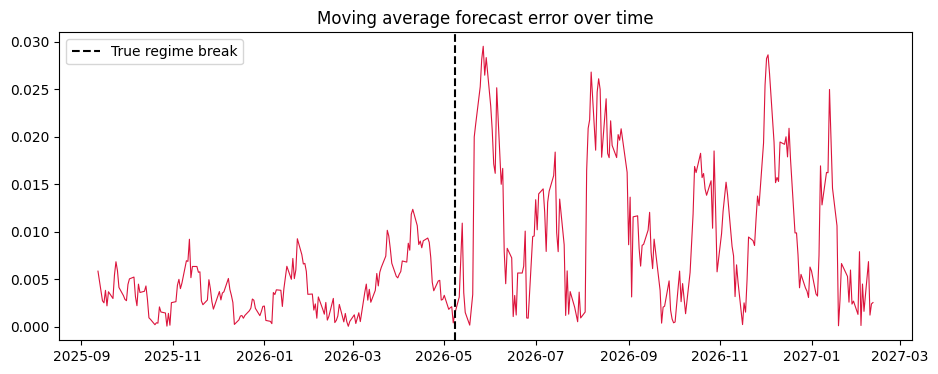

In [ ]:
# Cell 4: quantify the failure — error before vs after the regime break
df["error"] = np.abs(df["price"] - df["ma_forecast_next_day"])

error_before = df.loc[50:199, "error"].mean()   # well inside calm regime
error_after  = df.loc[200:249, "error"].mean()  # first 50 days of turbulent regime

print(f"Average error INSIDE calm regime:      {error_before:.4f}")
print(f"Average error RIGHT AFTER regime break: {error_after:.4f}")
print(f"Error increased by: {(error_after/error_before - 1)*100:.1f}%")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df["date"], df["error"], color="crimson", linewidth=0.8)
ax.axvline(df["date"].iloc[200], color="black", linestyle="--", label="True regime break")
ax.set_title("Moving average forecast error over time")
ax.legend()
plt.show()

## ARIMA

ARIMA trained ONLY on calm regime, forecasting into turbulence: RMSE = 0.0240


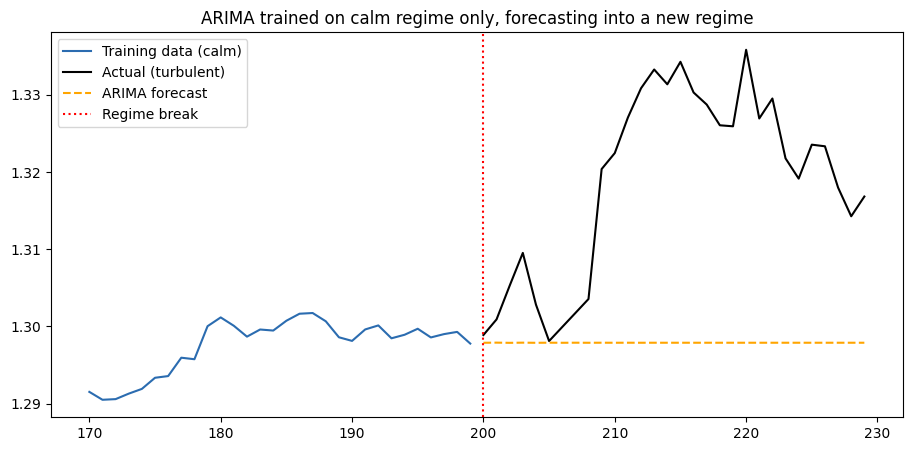

In [ ]:
# Cell 5: ARIMA trained purely on calm-regime data, forecasting into turbulence
from statsmodels.tsa.arima.model import ARIMA

price = df["price"].values

# Split the data into training and testing sets
train_a = price[:200] # Training data: first 200 data points (calm regime)
actual_a = price[200:230] # Actual data for comparison: next 30 data points (turbulent regime)

# Fit an ARIMA model to the training data
fit_a = ARIMA(train_a, order=(2, 1, 2)).fit() # Create and fit an ARIMA model with specified orders (p, d, q)
forecast_a = fit_a.forecast(steps=30) # Forecast the next 30 steps using the fitted model

# Calculate Root Mean Squared Error (RMSE) to evaluate forecast accuracy
rmse_a = np.sqrt(np.mean((forecast_a - actual_a) ** 2)) # Compare forecast with actual turbulent data
print(f"ARIMA trained ONLY on calm regime, forecasting into turbulence: RMSE = {rmse_a:.4f}") # Print the calculated RMSE

# Plot the results to visualize the forecast
fig, ax = plt.subplots(figsize=(11, 5)) # Create a new figure and a set of subplots
ax.plot(range(170, 200), train_a[170:], label="Training data (calm)", color="#2b6cb0") # Plot a portion of the training data
ax.plot(range(200, 230), actual_a, label="Actual (turbulent)", color="black") # Plot the actual turbulent data
ax.plot(range(200, 230), forecast_a, label="ARIMA forecast", color="orange", linestyle="--") # Plot the ARIMA forecast
ax.axvline(200, color="red", linestyle=":", label="Regime break") # Add a vertical line to indicate the regime break
ax.legend() # Display the legend
ax.set_title("ARIMA trained on calm regime only, forecasting into a new regime") # Set the plot title
plt.show() # Display the plot

What this plot proves, precisely: ARIMA trained on 200 days of calm data learned "this series barely moves, hovers around 1.298." So its entire 30-day forecast is essentially a flat line at that value — it has zero information suggesting a big directional move is coming, because nothing in its training data ever looked like that. It's not "wrong" in a buggy sense — it's doing exactly what a model should do with the data it was given. The failure isn't in the math, it's in the assumption that the training window represents what comes next

In [ ]:
# Cell 6: ARIMA trained on BLENDED data (spans both regimes) — same idea as before but with a "smarter" model
train_b = price[:250]
actual_b = price[250:280]

fit_b = ARIMA(train_b, order=(2, 1, 2)).fit()
forecast_b = fit_b.forecast(steps=30)
rmse_b = np.sqrt(np.mean((forecast_b - actual_b) ** 2))
print(f"ARIMA trained on BLENDED calm+turbulent data: RMSE = {rmse_b:.4f}")

# Compare directly against the moving-average baseline over the exact same window
ma = pd.Series(price).rolling(30).mean().shift(1)
ma_forecast_b = ma.values[250:280]
rmse_ma_b = np.sqrt(np.mean((ma_forecast_b - actual_b) ** 2))
print(f"Moving average baseline, same window: RMSE = {rmse_ma_b:.4f}")

ARIMA trained on BLENDED calm+turbulent data: RMSE = 0.0212
Moving average baseline, same window: RMSE = 0.0167


Cell 6 (Stage B): ARIMA trained on days 0-250 — calm days 0-200 PLUS the first 50 turbulent days 200-250 blended together as one training set — then forecasts days 250-280 (further into turbulence). It has seen some turbulence, but averaged in with calm data as if it's all one process.

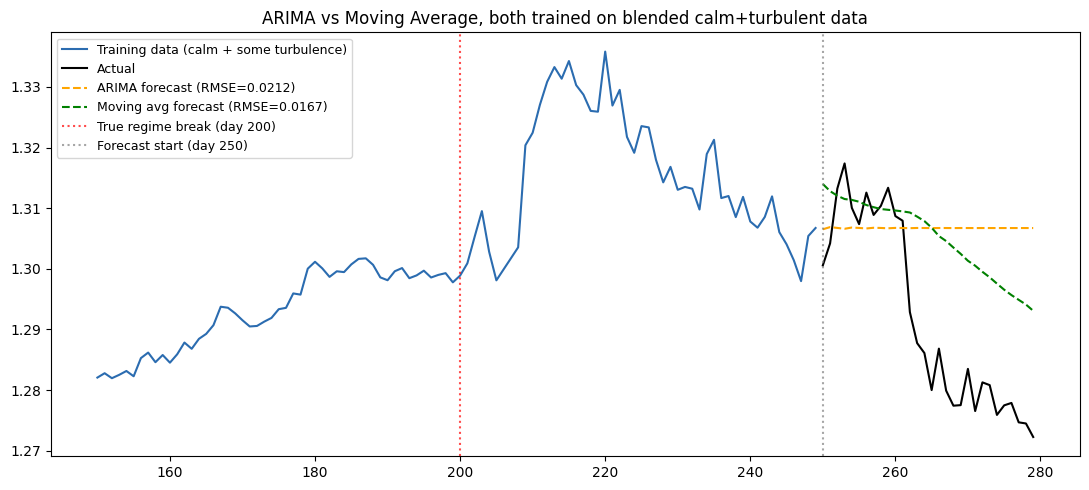

In [ ]:
# Cell 6b: visualize the blended-training comparison
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(range(150, 250), train_b[150:], label="Training data (calm + some turbulence)", color="#2b6cb0")
ax.plot(range(250, 280), actual_b, label="Actual", color="black", linewidth=1.5)
ax.plot(range(250, 280), forecast_b, label=f"ARIMA forecast (RMSE={rmse_b:.4f})", color="orange", linestyle="--")
ax.plot(range(250, 280), ma_forecast_b, label=f"Moving avg forecast (RMSE={rmse_ma_b:.4f})", color="green", linestyle="--")
ax.axvline(200, color="red", linestyle=":", alpha=0.7, label="True regime break (day 200)")
ax.axvline(250, color="gray", linestyle=":", alpha=0.7, label="Forecast start (day 250)")
ax.legend(loc="upper left", fontsize=9)
ax.set_title("ARIMA vs Moving Average, both trained on blended calm+turbulent data")
plt.tight_layout()
plt.show()

focus on **green line**,
The one-sentence takeaway from this specific chart: neither model saw the cliff coming, and neither one would have told you "this is now a fundamentally more dangerous/volatile period, treat forecasts with much less confidence" — which is exactly the missing capability we're about to build with regime detection.


## Stage 3:

**Prophet
What Prophet is, in plain terms: it's Meta's forecasting tool, built to be more automatic than ARIMA — you don't have to manually pick p/d/q settings. Its key extra feature: it tries to detect trend changepoints on its own during training, then fits different trend segments around them, rather than assuming one trend line for the whole series.**

In [ ]:
# Cell 7: Prophet setup and fit
from prophet import Prophet

# Prophet requires specific column names: 'ds' for date, 'y' for value
prophet_df = df[["date", "price"]].rename(columns={"date": "ds", "price": "y"})

train = prophet_df.iloc[:250]
actual = prophet_df.iloc[250:280]

model = Prophet(
    changepoint_prior_scale=0.05,   # how sensitive it is to detecting trend shifts
    daily_seasonality=False,
    weekly_seasonality=False,
    yearly_seasonality=False
)
model.fit(train)

future = model.make_future_dataframe(periods=30, freq="B")
forecast = model.predict(future)

forecast_vals = forecast["yhat"].iloc[250:280].values
actual_vals = actual["y"].values
rmse = np.sqrt(np.mean((forecast_vals - actual_vals) ** 2))
print(f"Prophet RMSE: {rmse:.4f}")

Prophet RMSE: 0.0298


In [ ]:
# Cell 8: check whether Prophet at least NOTICED the regime break, even if its forecast was mediocre
changepoints = model.changepoints
cp_deltas = model.params['delta'].mean(axis=0)
biggest_cp_idx = np.argmax(np.abs(cp_deltas))

print(f"Prophet's biggest detected trend changepoint: {changepoints.iloc[biggest_cp_idx]}")
print(f"The TRUE regime break was at: {df['date'].iloc[200]}")

Prophet's biggest detected trend changepoint: 2026-05-07 00:00:00
The TRUE regime break was at: 2026-05-08 00:00:00


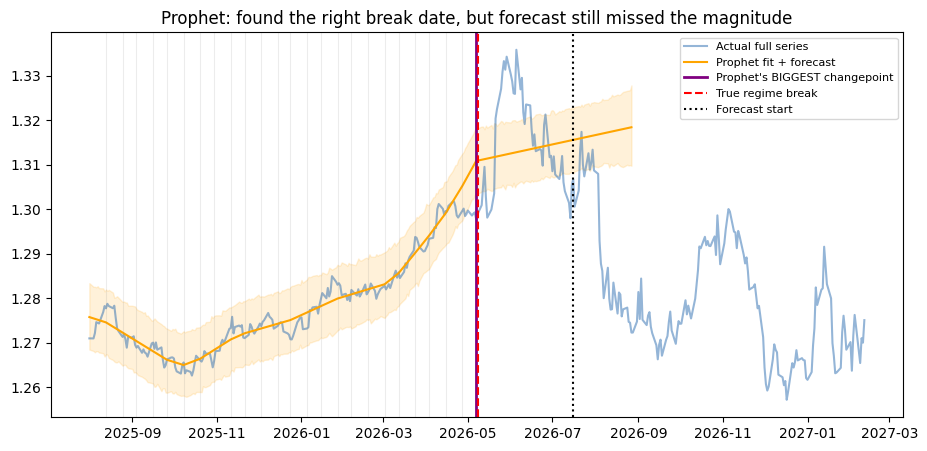

In [ ]:
# Cell 9: visualize it
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df["date"], df["price"], color="#2b6cb0", alpha=0.5, label="Actual full series")
ax.plot(forecast["ds"], forecast["yhat"], color="orange", label="Prophet fit + forecast")
ax.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"], color="orange", alpha=0.15)
for cp in changepoints:
    ax.axvline(cp, color="gray", alpha=0.15, linewidth=0.8)
ax.axvline(changepoints.iloc[biggest_cp_idx], color="purple", linewidth=2, label="Prophet's BIGGEST changepoint")
ax.axvline(df["date"].iloc[200], color="red", linestyle="--", label="True regime break")
ax.axvline(train["ds"].iloc[-1], color="black", linestyle=":", label="Forecast start")
ax.legend(fontsize=8)
ax.set_title("Prophet: found the right break date, but forecast still missed the magnitude")
plt.show()

This is the whole point of Stage 3, stated precisely: Prophet essentially localized the regime change almost perfectly — it knew something structurally important happened right around day 200. But knowing where the break is didn't translate into a good forecast of what comes after, because Prophet still tries to answer "what's the single next value," using a fairly generic trend+seasonality model on the segment after the break — and 50 days of post-break data wasn't enough to characterize the new regime's true volatility.

Prophet doesnt give you a single guess, it actually gives you a range


# Implementing Ruptures

Ruptures is like a metal detector: it beeps loudly and tells you where to dig. It doesn't tell you what you dug up.

In [ ]:
!pip install -q ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.8 MB/s eta 0:00:00


In [ ]:
# Cell 10: change-point detection, done correctly (on returns, not raw price)
import ruptures as rpt

price = df["price"].values
returns = np.diff(price)   # day-to-day changes

# Binary Segmentation: directly ask "find me the single most significant break"
algo = rpt.Binseg(model="rbf").fit(returns)
single_bp = algo.predict(n_bkps=1)

print(f"Detected breakpoint: {single_bp}")
print(f"True break: 200")

print(f"\nStd dev of returns BEFORE break: {returns[:200].std():.4f}")
print(f"Std dev of returns AFTER break:  {returns[200:].std():.4f}")

Detected breakpoint: [200, 399]
True break: 200

Std dev of returns BEFORE break: 0.0014
Std dev of returns AFTER break:  0.0044


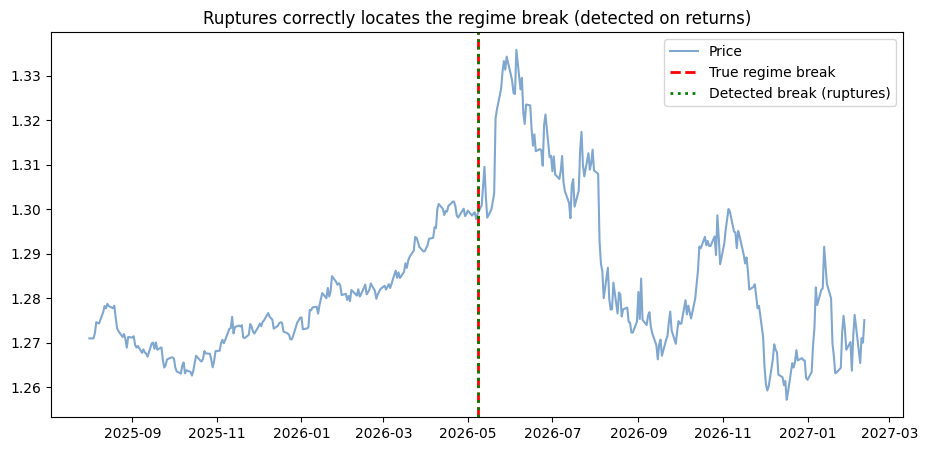

In [ ]:
# Cell 11: visualize it
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df["date"], df["price"], color="#2b6cb0", alpha=0.6, label="Price")
ax.axvline(df["date"].iloc[200], color="red", linestyle="--", linewidth=2, label="True regime break")
ax.axvline(df["date"].iloc[single_bp[0]], color="green", linestyle=":", linewidth=2, label="Detected break (ruptures)")
ax.legend()
ax.set_title("Ruptures correctly locates the regime break (detected on returns)")
plt.show()

Why HMM (Hidden Markov Model) Comes Next

We need something that answers the next natural questions: "Okay, something changed at day 200 — but what STATE are we in now, and how confident are we?"

What an HMM does, in plain terms: it assumes there are a small number of hidden "modes" or "states" that the data can be in (for us: something like "calm" and "turbulent"), and it learns:


What each state typically looks like (e.g., "calm" = small daily moves; "turbulent" = big daily moves)
Which state the data is in at every single day — not just at the one breakpoint, but continuously across the whole series
How likely it is to switch from one state to another day-to-day

Why this is the missing piece: ruptures gave us a single boundary line. HMM gives us an ongoing, updating answer to "which regime are we in right now, today" — which is exactly what a live dashboard needs to say to a user, and exactly what an LLM would need in order to write something like: "We are currently in a high-volatility regime, which began on [date]."

# hmm

In [ ]:
# Cell 12: HMM regime detection, done correctly
!pip install -q hmmlearn
from hmmlearn import hmm

returns = np.diff(price)

# Standardize -- keeps the optimizer numerically stable
returns_scaled = (returns - returns.mean()) / returns.std()
returns_scaled = returns_scaled.reshape(-1, 1)  # HMM expects 2D input

# Tell it to find 2 hidden states (we're assuming calm vs turbulent)
model = hmm.GaussianHMM(n_components=2, covariance_type="diag", n_iter=200, random_state=42)
model.fit(returns_scaled)

hidden_states = model.predict(returns_scaled)

means = model.means_.flatten()
covars = model.covars_.flatten()
for i in range(2):
    print(f"State {i}: mean={means[i]:.4f}, std={np.sqrt(covars[i]):.4f}")

# The state with bigger spread (std) is our "turbulent" regime
calm_state = np.argmin(covars)
turbulent_state = np.argmax(covars)
print(f"State {calm_state} = CALM, State {turbulent_state} = TURBULENT")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.3 MB/s eta 0:00:00
State 0: mean=0.0408, std=0.4244
State 1: mean=-0.0410, std=1.3497
State 0 = CALM, State 1 = TURBULENT


In [ ]:
# Cell 13: check accuracy against the ground truth
true_labels = np.array([0]*200 + [1]*199)  # returns array is 1 shorter than price
predicted = (hidden_states == turbulent_state).astype(int)
accuracy = (predicted == true_labels).mean()
print(f"Accuracy vs true regime labels: {accuracy*100:.1f}%")

first_turbulent_day = np.argmax(hidden_states == turbulent_state)
print(f"First day HMM calls turbulent: {first_turbulent_day} (true break: day 200)")

Accuracy vs true regime labels: 99.7%
First day HMM calls turbulent: 201 (true break: day 200)


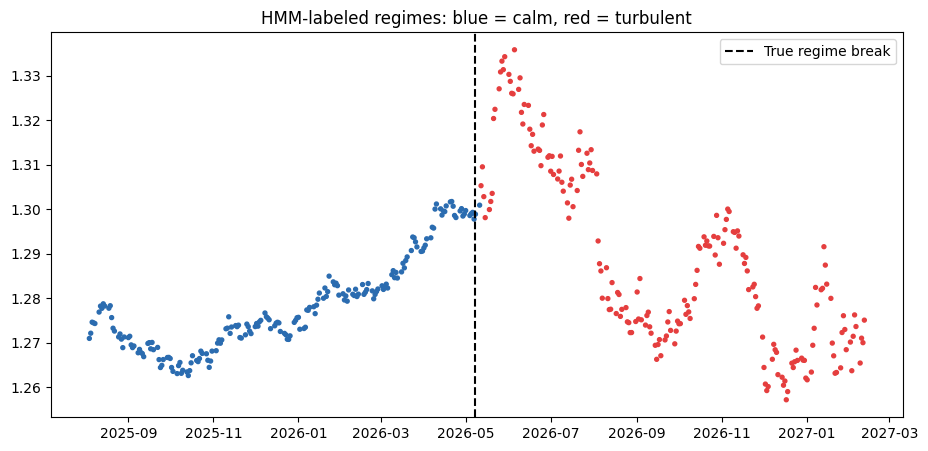

In [ ]:
# Cell 14: visualize the regime labels over the whole series
fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#2b6cb0" if s == calm_state else "#e53e3e" for s in hidden_states]
ax.scatter(df["date"].iloc[1:], price[1:], c=colors, s=8)
ax.axvline(df["date"].iloc[200], color="black", linestyle="--", label="True regime break")
ax.set_title("HMM-labeled regimes: blue = calm, red = turbulent")
ax.legend()
plt.show()

In [ ]:
import numpy as np
np.set_printoptions(suppress=True, precision=4)
print(model.transmat_)
np.set_printoptions(suppress=False, precision=8) # Reset to default for other outputs

[[0.995 0.005]
 [0.    1.   ]]


Read row 1 as: "if we're in calm today, 99.5% chance we're still calm tomorrow, 0.5% chance we flip to turbulent." Row 2: "if we're in turbulent today, we're virtually certain to still be turbulent tomorrow." This number — how "sticky" each regime is — is genuinely useful output for your dashboard later (e.g., "turbulent regimes in this series have historically persisted for X days on average").



##Q. What ruptures + HMM actually hands you

After running it, you have, for any point in time:
1. **Which regime we're currently in** (e.g. "turbulent")
2. **How long we've been in it** (since day 200, so X days)
3. **That regime's typical behavior** (its average drift, its typical volatility)
4. **How "sticky" regimes have historically been** (from the transition matrix — e.g. "turbulent periods here tend to last ~6-8 weeks before flipping back")

That's it. It's a **live, ongoing description of the present**, not a prediction of the future. The question "what do I DO with that" is the right one to ask, because a regime label by itself doesn't automatically produce value.

## The applications — in increasing order of what you're building toward

**1. Honest uncertainty communication (what we just proved)**
Instead of a fake-precise forecast, you say "we're in regime X, so expect swings within roughly this range" — which we showed is actually more trustworthy than a naive forecast pretending to be precise. This alone is a legitimate, sellable output.

**2. Risk/position sizing (a real-world financial use)**
If you're managing exposure to something (a trading position, a hedging decision, even just personal financial risk-taking), knowing "we just entered a high-volatility regime" is actionable: reduce size, widen stop-losses, expect bigger swings than usual — even without predicting direction at all.

**3. Context for any OTHER model or decision (this is the big one)**
This is probably the most defensible, general-purpose application: use the regime label as an **input feature** to something else. For example — if you had a fraud detection model (relevant to your background), knowing "the transaction volume series just entered an anomalous regime" could be a feature that makes the fraud model more sensitive during unusual periods. Regime labels rarely stand alone in serious systems — they usually feed into a bigger decision downstream.

**4. Explanation and narration (this is literally your project)**
The regime label + its statistics becomes the **input to the LLM**, which turns "state=turbulent, drift=-0.0005, vol=0.0044, since=day 200, historical persistence=~45 days" into a plain-English brief a human can actually read and act on. The LLM's job is purely to translate structured regime facts into language — it's not doing the detection itself, and it's not inventing insight from nothing.

**5. Self-monitoring / accuracy tracking (your v3 idea from earlier)**
Log every regime call, and later check: did the "turbulent" label actually correspond to a period of bigger, more chaotic moves? Did the regime last roughly as long as history suggested it would? This turns the regime detector into something you can grade over time — which is rare and valuable in portfolio projects.

## The honest boundary — what it does NOT do

It will never tell you "the price will go up" or "sell now." It only ever answers **"what kind of environment are we in, and how much should that change how we act or how much we trust other predictions."** That's a narrower claim than a price predictor makes — but it's a claim you can actually back up with evidence, which is exactly why it survived our stress-testing and a full price predictor wouldn't have.